                                     IPL Match & Player Performance Analytics using Python

Dataset Name:

IPL Matches and Ball-by-Ball Dataset (2008–2025)


PROJECT OVERVIEW:

The objective is to transform raw IPL data into actionable insights that can support decision-making for teams, analysts, and cricket enthusiasts.

Objectives:

*Analyze IPL match and player performance.
*Clean and preprocess raw cricket data.
*Perform exploratory data analysis (EDA).
*Discover trends in batting, bowling, venues, and team performance.

import

In [43]:
import pandas as pd
import numpy as np

load dataset

In [46]:
matches = pd.read_csv("D:\ipl\matches.csv")
deliveries = pd.read_csv("D:\ipl\deliveries.csv")

inspecting data

In [47]:
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [48]:
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [49]:
matches.shape

(1095, 20)

In [50]:
deliveries.shape

(260920, 17)

In [51]:
matches.columns

Index(['id', 'season', 'city', 'date', 'match_type', 'player_of_match',
       'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner',
       'result', 'result_margin', 'target_runs', 'target_overs', 'super_over',
       'method', 'umpire1', 'umpire2'],
      dtype='object')

In [52]:
deliveries.columns

Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs',
       'total_runs', 'extras_type', 'is_wicket', 'player_dismissed',
       'dismissal_kind', 'fielder'],
      dtype='object')

In [53]:
matches.info


<bound method DataFrame.info of            id   season        city        date   match_type  player_of_match  \
0      335982  2007/08   Bangalore  2008-04-18       League      BB McCullum   
1      335983  2007/08  Chandigarh  2008-04-19       League       MEK Hussey   
2      335984  2007/08       Delhi  2008-04-19       League      MF Maharoof   
3      335985  2007/08      Mumbai  2008-04-20       League       MV Boucher   
4      335986  2007/08     Kolkata  2008-04-20       League        DJ Hussey   
...       ...      ...         ...         ...          ...              ...   
1090  1426307     2024   Hyderabad  2024-05-19       League  Abhishek Sharma   
1091  1426309     2024   Ahmedabad  2024-05-21  Qualifier 1         MA Starc   
1092  1426310     2024   Ahmedabad  2024-05-22   Eliminator         R Ashwin   
1093  1426311     2024     Chennai  2024-05-24  Qualifier 2    Shahbaz Ahmed   
1094  1426312     2024     Chennai  2024-05-26        Final         MA Starc   

       

In [54]:
deliveries.info

<bound method DataFrame.info of         match_id  inning           batting_team                 bowling_team  \
0         335982       1  Kolkata Knight Riders  Royal Challengers Bangalore   
1         335982       1  Kolkata Knight Riders  Royal Challengers Bangalore   
2         335982       1  Kolkata Knight Riders  Royal Challengers Bangalore   
3         335982       1  Kolkata Knight Riders  Royal Challengers Bangalore   
4         335982       1  Kolkata Knight Riders  Royal Challengers Bangalore   
...          ...     ...                    ...                          ...   
260915   1426312       2  Kolkata Knight Riders          Sunrisers Hyderabad   
260916   1426312       2  Kolkata Knight Riders          Sunrisers Hyderabad   
260917   1426312       2  Kolkata Knight Riders          Sunrisers Hyderabad   
260918   1426312       2  Kolkata Knight Riders          Sunrisers Hyderabad   
260919   1426312       2  Kolkata Knight Riders          Sunrisers Hyderabad   

       

In [55]:
matches.dtypes

id                   int64
season              object
city                object
date                object
match_type          object
player_of_match     object
venue               object
team1               object
team2               object
toss_winner         object
toss_decision       object
winner              object
result              object
result_margin      float64
target_runs        float64
target_overs       float64
super_over          object
method              object
umpire1             object
umpire2             object
dtype: object

In [56]:
deliveries.dtypes

match_id             int64
inning               int64
batting_team        object
bowling_team        object
over                 int64
ball                 int64
batter              object
bowler              object
non_striker         object
batsman_runs         int64
extra_runs           int64
total_runs           int64
extras_type         object
is_wicket            int64
player_dismissed    object
dismissal_kind      object
fielder             object
dtype: object

In [57]:
matches.describe()

,id,result_margin,target_runs,target_overs
count,1.095000e+03,1076.000000,1092.000000,1092.000000
mean,9.048283e+05,17.259294,165.684066,19.759341
std,3.677402e+05,21.787444,33.427048,1.581108
min,3.359820e+05,1.000000,43.000000,5.000000
25%,5.483315e+05,6.000000,146.000000,20.000000
50%,9.809610e+05,8.000000,166.000000,20.000000
75%,1.254062e+06,20.000000,187.000000,20.000000
max,1.426312e+06,146.000000,288.000000,20.000000


In [58]:
matches.isnull().sum()


id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64

In [59]:
deliveries.isnull().sum()

match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batter                   0
bowler                   0
non_striker              0
batsman_runs             0
extra_runs               0
total_runs               0
extras_type         246795
is_wicket                0
player_dismissed    247970
dismissal_kind      247970
fielder             251566
dtype: int64

In [60]:
matches.duplicated().sum()

np.int64(0)

In [61]:
deliveries.duplicated().sum()

np.int64(0)

In [62]:

# Fill missing values in matches dataset

matches["city"] = matches["city"].fillna("Unknown")

matches["player_of_match"] = matches["player_of_match"].fillna("No Award")

matches["winner"] = matches["winner"].fillna("No Result")

matches["result_margin"] = matches["result_margin"].fillna(0)

matches["target_runs"] = matches["target_runs"].fillna(0)

matches["target_overs"] = matches["target_overs"].fillna(0)

matches["method"] = matches["method"].fillna("Normal")

In [63]:
deliveries["extras_type"] = deliveries["extras_type"].fillna("None")

deliveries["player_dismissed"] = deliveries["player_dismissed"].fillna("None")

deliveries["dismissal_kind"] = deliveries["dismissal_kind"].fillna("Not Out")

deliveries["fielder"] = deliveries["fielder"].fillna("None")

In [64]:

matches.isnull().sum()

id                 0
season             0
city               0
date               0
match_type         0
player_of_match    0
venue              0
team1              0
team2              0
toss_winner        0
toss_decision      0
winner             0
result             0
result_margin      0
target_runs        0
target_overs       0
super_over         0
method             0
umpire1            0
umpire2            0
dtype: int64

In [65]:
deliveries.isnull().sum()

match_id            0
inning              0
batting_team        0
bowling_team        0
over                0
ball                0
batter              0
bowler              0
non_striker         0
batsman_runs        0
extra_runs          0
total_runs          0
extras_type         0
is_wicket           0
player_dismissed    0
dismissal_kind      0
fielder             0
dtype: int64

In [66]:
matches.duplicated().sum()

np.int64(0)

In [67]:
deliveries.duplicated().sum()

np.int64(0)

In [68]:
matches["team1"].unique()

array(['Royal Challengers Bangalore', 'Kings XI Punjab',
       'Delhi Daredevils', 'Mumbai Indians', 'Kolkata Knight Riders',
       'Rajasthan Royals', 'Deccan Chargers', 'Chennai Super Kings',
       'Kochi Tuskers Kerala', 'Pune Warriors', 'Sunrisers Hyderabad',
       'Gujarat Lions', 'Rising Pune Supergiants',
       'Rising Pune Supergiant', 'Delhi Capitals', 'Punjab Kings',
       'Lucknow Super Giants', 'Gujarat Titans',
       'Royal Challengers Bengaluru'], dtype=object)

In [69]:
matches["team2"].unique()

array(['Kolkata Knight Riders', 'Chennai Super Kings', 'Rajasthan Royals',
       'Royal Challengers Bangalore', 'Deccan Chargers',
       'Kings XI Punjab', 'Delhi Daredevils', 'Mumbai Indians',
       'Kochi Tuskers Kerala', 'Pune Warriors', 'Sunrisers Hyderabad',
       'Rising Pune Supergiants', 'Gujarat Lions',
       'Rising Pune Supergiant', 'Delhi Capitals', 'Punjab Kings',
       'Gujarat Titans', 'Lucknow Super Giants',
       'Royal Challengers Bengaluru'], dtype=object)

In [70]:
deliveries["batting_team"].unique()
deliveries["bowling_team"].unique()

array(['Royal Challengers Bangalore', 'Kolkata Knight Riders',
       'Kings XI Punjab', 'Chennai Super Kings', 'Delhi Daredevils',
       'Rajasthan Royals', 'Mumbai Indians', 'Deccan Chargers',
       'Kochi Tuskers Kerala', 'Pune Warriors', 'Sunrisers Hyderabad',
       'Rising Pune Supergiants', 'Gujarat Lions',
       'Rising Pune Supergiant', 'Delhi Capitals', 'Punjab Kings',
       'Gujarat Titans', 'Lucknow Super Giants',
       'Royal Challengers Bengaluru'], dtype=object)

In [71]:
team_name_changes = {
    "Delhi Daredevils": "Delhi Capitals",
    "Kings XI Punjab": "Punjab Kings"
}

In [72]:
matches.replace(team_name_changes, inplace=True)

In [73]:
deliveries.replace(team_name_changes, inplace=True)

In [74]:
matches["date"] = pd.to_datetime(matches["date"])

In [75]:
matches["year"] = matches["date"].dt.year

In [76]:
matches["day"] = matches["date"].dt.day_name()

In [77]:
deliveries["is_boundary"] = deliveries["batsman_runs"].apply(
    lambda x: 1 if x in [4, 6] else 0
)

In [78]:
deliveries["is_dotball"] = deliveries["total_runs"].apply(
    lambda x: 1 if x == 0 else 0
)

In [79]:
def match_phase(over):
    if over <= 6:
        return "Powerplay"
    elif over <= 15:
        return "Middle Overs"
    else:
        return "Death Overs"

deliveries["match_phase"] = deliveries["over"].apply(match_phase)

In [80]:
deliveries[["over", "match_phase"]].head(20)

,over,match_phase
0,0,Powerplay
1,0,Powerplay
2,0,Powerplay
3,0,Powerplay
4,0,Powerplay
5,0,Powerplay
6,0,Powerplay
7,1,Powerplay
8,1,Powerplay
9,1,Powerplay


In [81]:
matches.dtypes

id                          int64
season                     object
city                       object
date               datetime64[ns]
match_type                 object
player_of_match            object
venue                      object
team1                      object
team2                      object
toss_winner                object
toss_decision              object
winner                     object
result                     object
result_margin             float64
target_runs               float64
target_overs              float64
super_over                 object
method                     object
umpire1                    object
umpire2                    object
year                        int32
day                        object
dtype: object

In [82]:
matches["result_margin"] = matches["result_margin"].astype(int)

matches["target_runs"] = matches["target_runs"].astype(int)

matches["target_overs"] = matches["target_overs"].astype(int)

matches["month"] = matches["date"].dt.month_name()

In [83]:
matches.dtypes

id                          int64
season                     object
city                       object
date               datetime64[ns]
match_type                 object
player_of_match            object
venue                      object
team1                      object
team2                      object
toss_winner                object
toss_decision              object
winner                     object
result                     object
result_margin               int64
target_runs                 int64
target_overs                int64
super_over                 object
method                     object
umpire1                    object
umpire2                    object
year                        int32
day                        object
month                      object
dtype: object

In [84]:
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,...,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2,year,day,month
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,...,140,223,20,N,Normal,Asad Rauf,RE Koertzen,2008,Friday,April
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Punjab Kings,Chennai Super Kings,Chennai Super Kings,...,33,241,20,N,Normal,MR Benson,SL Shastri,2008,Saturday,April
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Capitals,Rajasthan Royals,Rajasthan Royals,...,9,130,20,N,Normal,Aleem Dar,GA Pratapkumar,2008,Saturday,April
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,...,5,166,20,N,Normal,SJ Davis,DJ Harper,2008,Sunday,April
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,...,5,111,20,N,Normal,BF Bowden,K Hariharan,2008,Sunday,April


In [85]:
deliveries.dtypes

match_id             int64
inning               int64
batting_team        object
bowling_team        object
over                 int64
ball                 int64
batter              object
bowler              object
non_striker         object
batsman_runs         int64
extra_runs           int64
total_runs           int64
extras_type         object
is_wicket            int64
player_dismissed    object
dismissal_kind      object
fielder             object
is_boundary          int64
is_dotball           int64
match_phase         object
dtype: object

In [86]:
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder,is_boundary,is_dotball,match_phase
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,None,Not Out,None,0,0,Powerplay
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,None,0,None,Not Out,None,0,1,Powerplay
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,None,Not Out,None,0,0,Powerplay
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,None,0,None,Not Out,None,0,1,Powerplay
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,None,0,None,Not Out,None,0,1,Powerplay


In [87]:
matches.to_csv("D:\ipl\cleaned_matches.csv", index=False)

deliveries.to_csv("D:\ipl\cleaned_deliveries.csv", index=False)

In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [89]:
matches = pd.read_csv("D:\ipl\cleaned_matches.csv")
deliveries = pd.read_csv("D:\ipl\cleaned_deliveries.csv")

In [90]:
matches.shape

(1095, 23)

Which Team Has Won the Most Matches?

In [91]:
team_wins = matches["winner"].value_counts()

team_wins

winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bangalore    116
Delhi Capitals                 115
Rajasthan Royals               112
Punjab Kings                   112
Sunrisers Hyderabad             88
Deccan Chargers                 29
Gujarat Titans                  28
Lucknow Super Giants            24
Gujarat Lions                   13
Pune Warriors                   12
Rising Pune Supergiant          10
Royal Challengers Bengaluru      7
Kochi Tuskers Kerala             6
Rising Pune Supergiants          5
No Result                        5
Name: count, dtype: int64

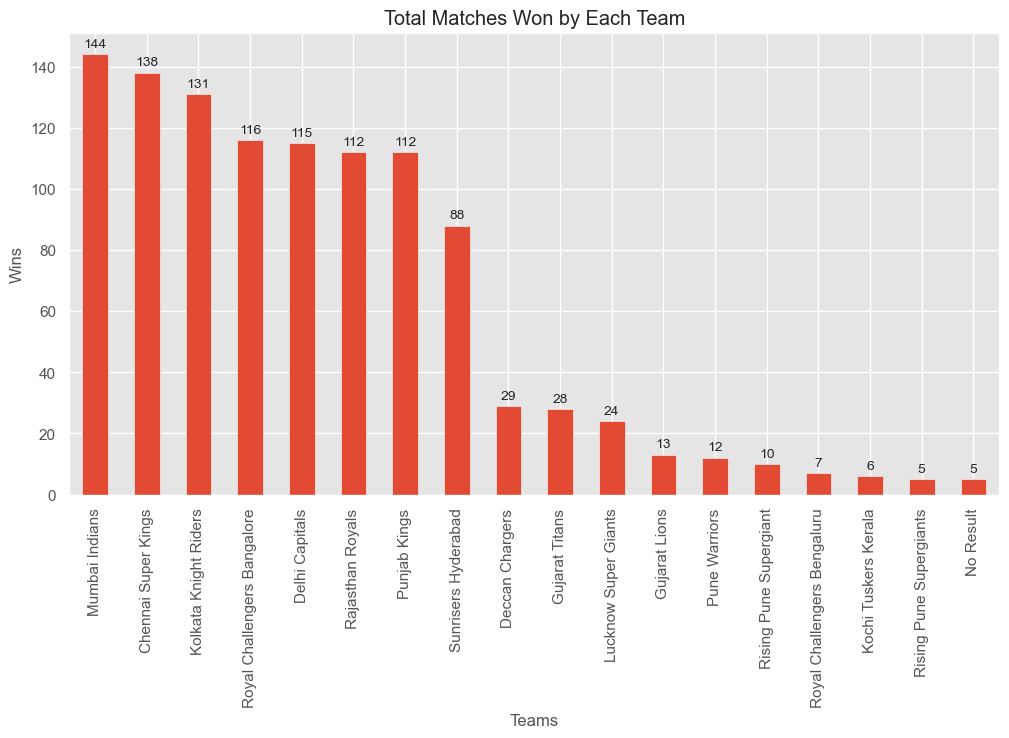

In [92]:
plt.figure(figsize=(12,6))

ax=team_wins.plot(kind="bar")

plt.title("Total Matches Won by Each Team")

plt.xlabel("Teams")

plt.ylabel("Wins")

plt.xticks(rotation=90)
ax.bar_label(ax.containers[0], padding=3)
plt.show()

Does Winning the Toss Increase Winning Chances?

In [25]:
toss_win_match = matches[matches["toss_winner"] == matches["winner"]]

percentage = len(toss_win_match) / len(matches) * 100

print(round(percentage,2))

50.59


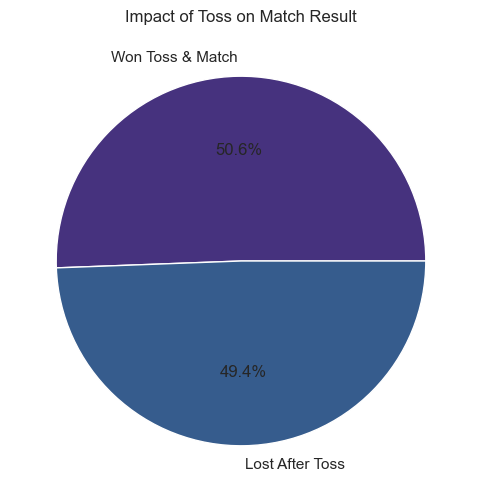

In [26]:
labels = ["Won Toss & Match","Lost After Toss"]

values = [
len(toss_win_match),
len(matches)-len(toss_win_match)
]

plt.figure(figsize=(6,6))

plt.pie(values,
labels=labels,
autopct="%1.1f%%")

plt.title("Impact of Toss on Match Result")

plt.show()

Which Stadium Hosted the Most Matches?

In [27]:
venue = matches["venue"].value_counts()

venue.head(10)

venue
Eden Gardens                                  77
Wankhede Stadium                              73
M Chinnaswamy Stadium                         65
Feroz Shah Kotla                              60
Rajiv Gandhi International Stadium, Uppal     49
MA Chidambaram Stadium, Chepauk               48
Sawai Mansingh Stadium                        47
Dubai International Cricket Stadium           46
Wankhede Stadium, Mumbai                      45
Punjab Cricket Association Stadium, Mohali    35
Name: count, dtype: int64

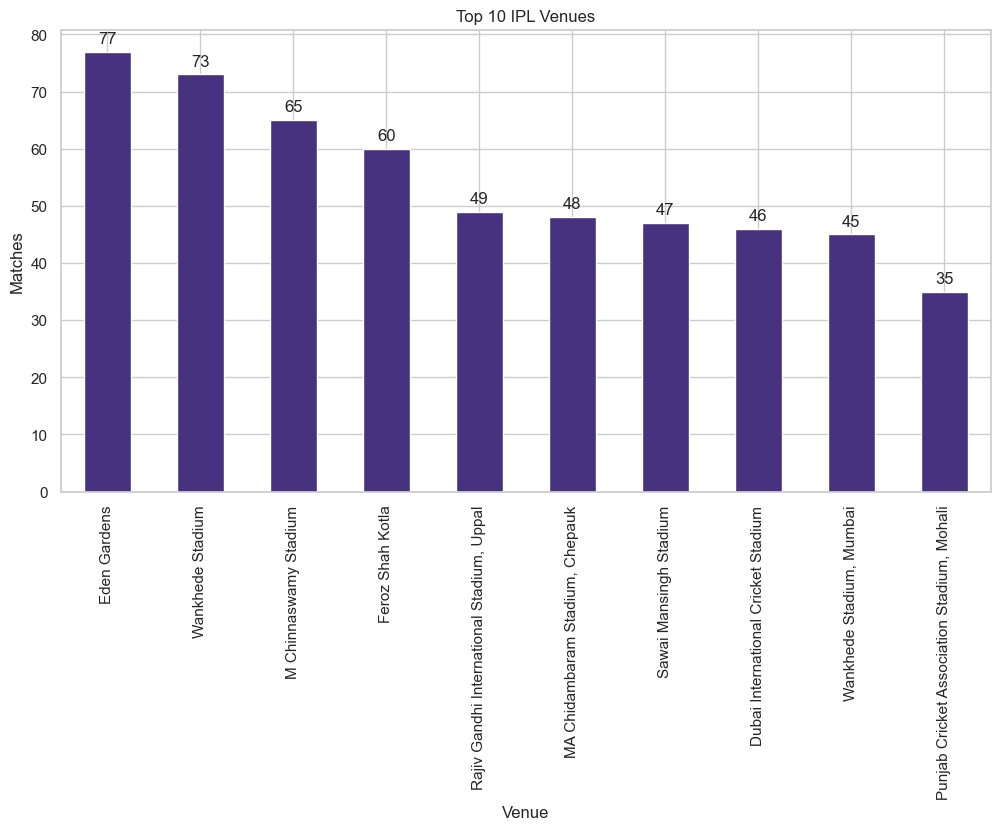

In [28]:
plt.figure(figsize=(12,6))

ax=venue.head(10).plot(kind="bar")

plt.title("Top 10 IPL Venues")

plt.xlabel("Venue")

plt.ylabel("Matches")
ax.bar_label(ax.containers[0], padding=4)
plt.xticks(rotation=90)

plt.show()

Which Players Won the Most "Player of the Match" Awards?

In [29]:
player=matches['player_of_match'].value_counts()
player

player_of_match
AB de Villiers       25
CH Gayle             22
RG Sharma            19
DA Warner            18
V Kohli              18
                     ..
NV Ojha               1
KV Sharma             1
Washington Sundar     1
PD Collingwood        1
Shahbaz Ahmed         1
Name: count, Length: 292, dtype: int64

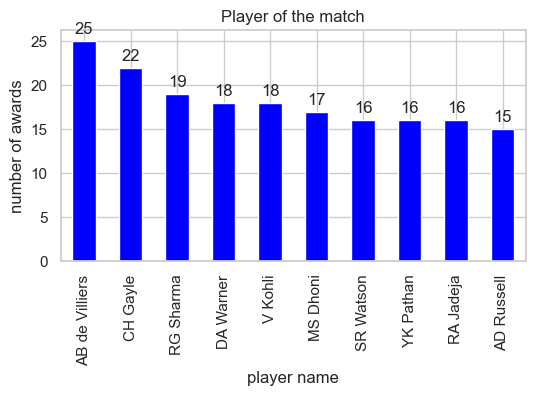

In [30]:
plt.figure(figsize=(6,3))
ax=player.head(10).plot(kind="bar",color="blue")
plt.xlabel("player name")
plt.ylabel("number of awards")
plt.title("Player of the match")
ax.bar_label(ax.containers[0],padding=3)
plt.xticks(rotation=90)
plt.show()


Which Toss Decision Is Preferred(field or bat)?

In [31]:
decision=matches["toss_decision"].value_counts()

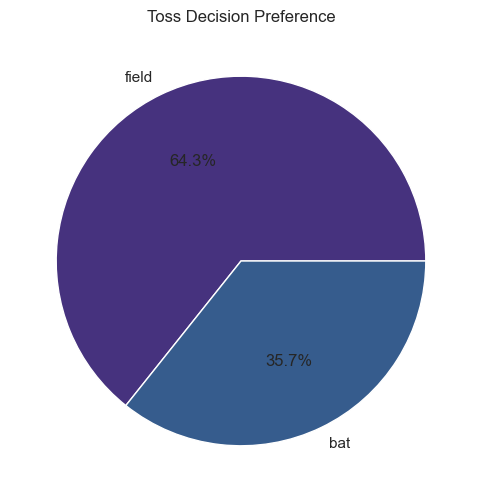

In [32]:
plt.figure(figsize=(6,6))

decision.plot(
kind="pie",
autopct="%1.1f%%"
)

plt.ylabel("")

plt.title("Toss Decision Preference")

plt.show()

Which City Hosted the Most IPL Matches?

In [33]:
city = matches["city"].value_counts()

city.head(10)

city
Mumbai        173
Kolkata        93
Delhi          90
Chennai        85
Hyderabad      77
Bangalore      65
Chandigarh     61
Jaipur         57
Unknown        51
Pune           51
Name: count, dtype: int64

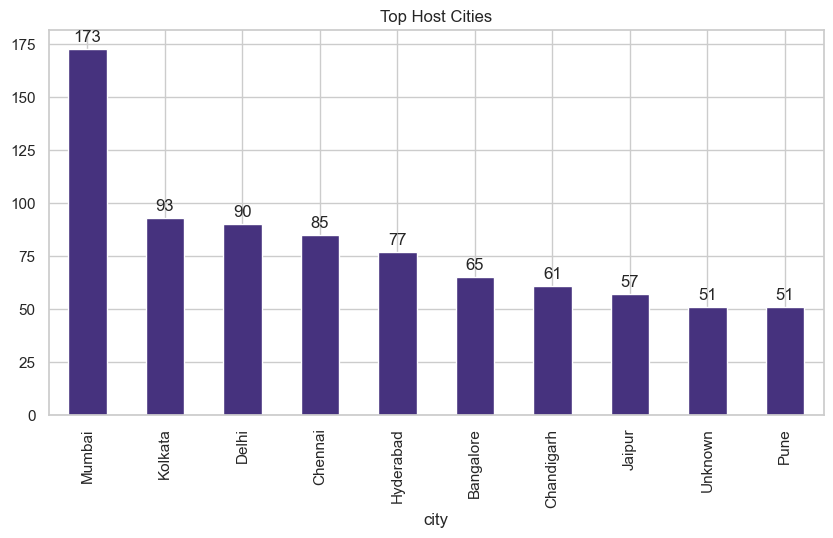

In [34]:
plt.figure(figsize=(10,5))

ax=city.head(10).plot(kind="bar")

plt.title("Top Host Cities")

plt.xticks(rotation=90)
ax.bar_label(ax.containers[0],padding=3)
plt.show()

count of super overs

In [35]:
s=matches.super_over.value_counts()
s



super_over
N    1081
Y      14
Name: count, dtype: int64

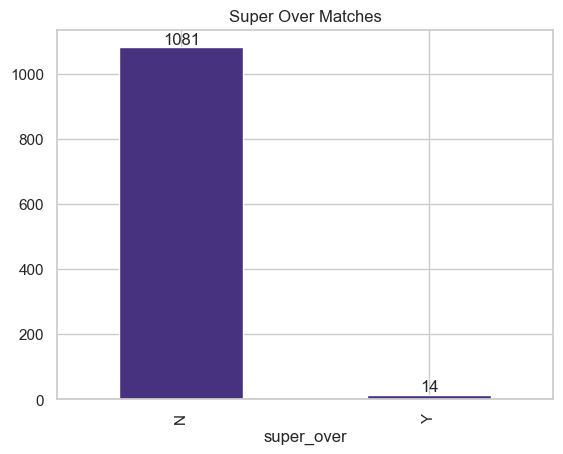

In [36]:
ax=s.plot(
kind="bar"
)
ax.bar_label(ax.containers[0])
plt.title("Super Over Matches")

plt.show()

Matches Played Every Season

In [37]:
season = matches["season"].value_counts().sort_index()

season

season
2007/08    58
2009       57
2009/10    60
2011       73
2012       74
2013       76
2014       60
2015       59
2016       60
2017       59
2018       60
2019       60
2020/21    60
2021       60
2022       74
2023       74
2024       71
Name: count, dtype: int64

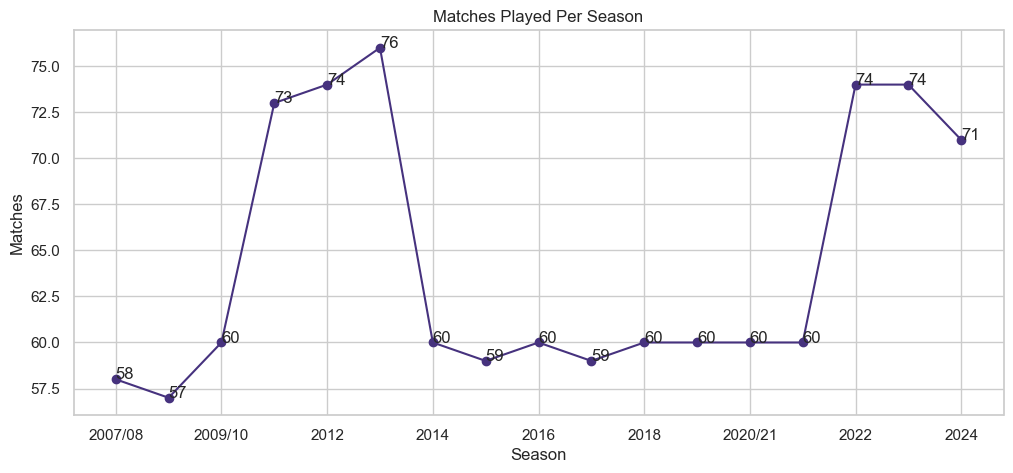

In [38]:
plt.figure(figsize=(12,5))

season.plot(marker="o")

for i, v in enumerate(season):
    plt.text(i, v, v)

plt.title("Matches Played Per Season")
plt.xlabel("Season")
plt.ylabel("Matches")
plt.grid(True)

plt.show()

match result type

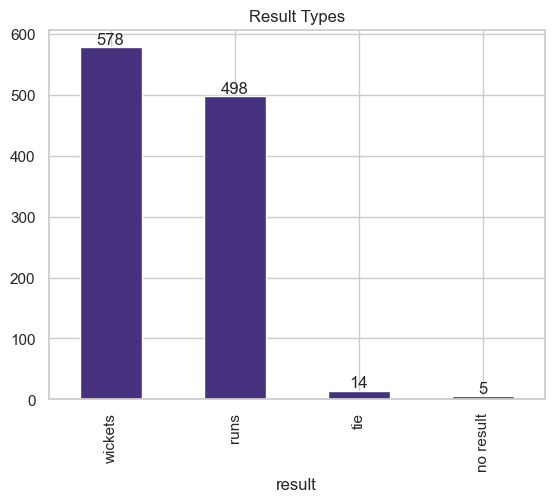

In [39]:
ax=matches["result"].value_counts().plot(
kind="bar"
)
ax.bar_label(ax.containers[0])
plt.title("Result Types")

plt.show()

Top 10 Run Scorers

In [40]:
top_runs = deliveries.groupby("batter")["batsman_runs"].sum().sort_values(ascending=False)

top_runs.head(10)

batter
V Kohli           8014
S Dhawan          6769
RG Sharma         6630
DA Warner         6567
SK Raina          5536
MS Dhoni          5243
AB de Villiers    5181
CH Gayle          4997
RV Uthappa        4954
KD Karthik        4843
Name: batsman_runs, dtype: int64

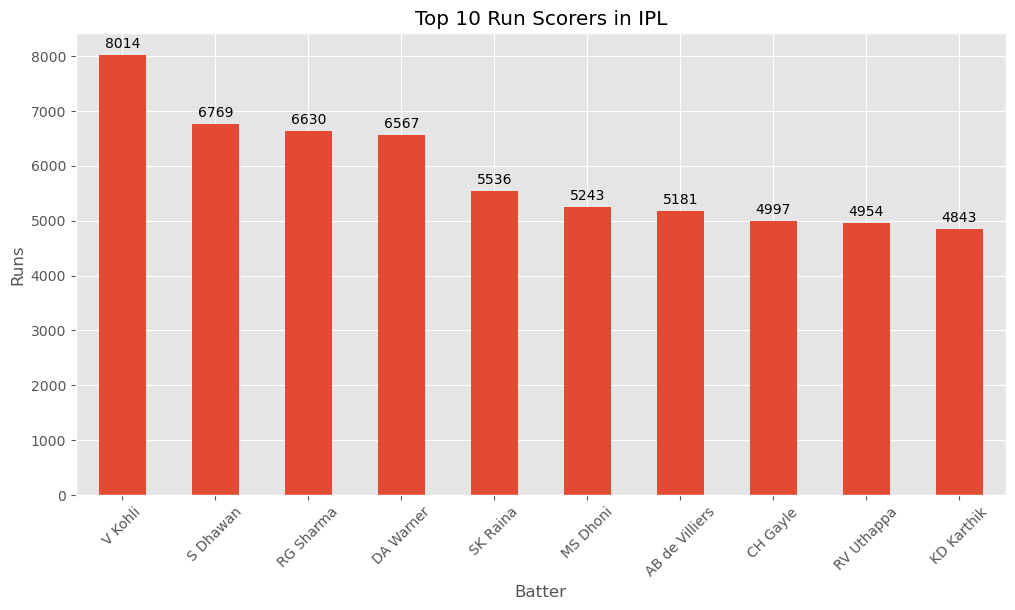

In [7]:
plt.figure(figsize=(12,6))

ax = top_runs.head(10).plot(kind="bar")

ax.bar_label(ax.containers[0], padding=3)

plt.title("Top 10 Run Scorers in IPL")

plt.xlabel("Batter")

plt.ylabel("Runs")

plt.xticks(rotation=45)

plt.show()

Top Wicket Takers

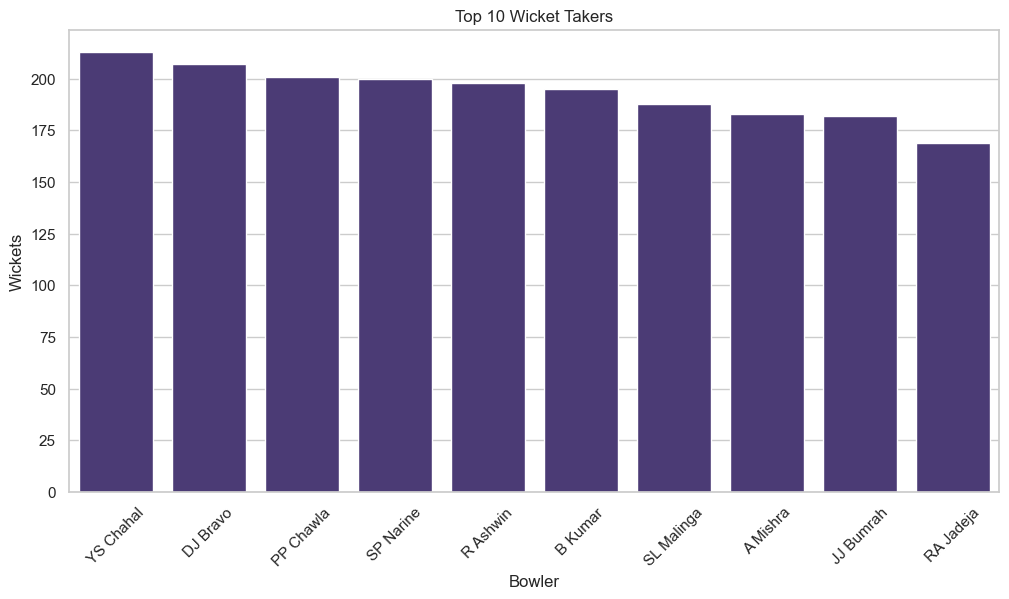

In [42]:
top_wickets = (
    deliveries.groupby("bowler")["is_wicket"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(12,6))

sns.barplot(data=top_wickets, x="bowler", y="is_wicket")

plt.title("Top 10 Wicket Takers")
plt.xlabel("Bowler")
plt.ylabel("Wickets")
plt.xticks(rotation=45)

plt.show()

Top 10 Batters by Runs

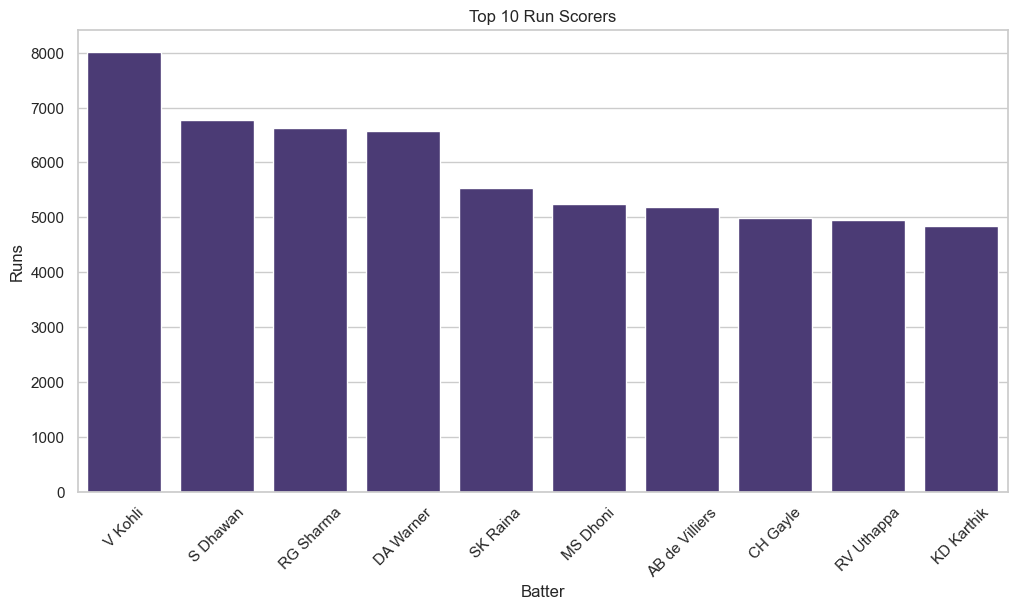

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

top_runs = (
    deliveries.groupby("batter")["batsman_runs"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(12,6))

sns.barplot(data=top_runs, x="batter", y="batsman_runs")

plt.title("Top 10 Run Scorers")
plt.xlabel("Batter")
plt.ylabel("Runs")
plt.xticks(rotation=45)

plt.show()

Most Boundaries

In [10]:
boundaries = deliveries[deliveries["is_boundary"] == 1]

boundary_count = boundaries.groupby("batter")["is_boundary"].sum().sort_values(ascending=False)

boundary_count.head(10)

batter
V Kohli           981
S Dhawan          921
DA Warner         899
RG Sharma         880
CH Gayle          767
SK Raina          710
AB de Villiers    667
RV Uthappa        663
KD Karthik        627
MS Dhoni          615
Name: is_boundary, dtype: int64

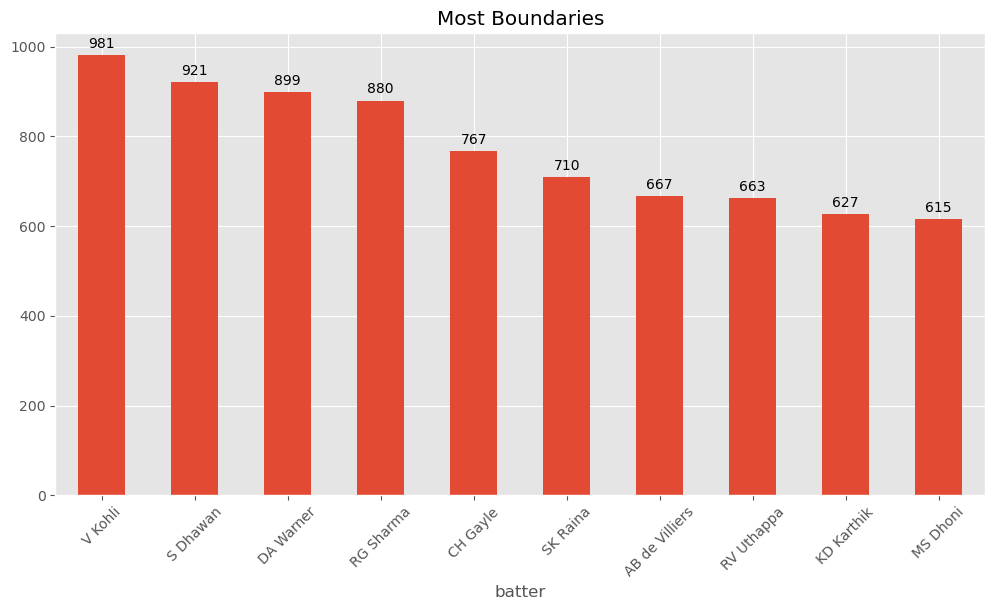

In [11]:
plt.figure(figsize=(12,6))

ax = boundary_count.head(10).plot(kind="bar")

ax.bar_label(ax.containers[0], padding=3)

plt.title("Most Boundaries")

plt.xticks(rotation=45)

plt.show()

dot balls

In [12]:
dotballs = deliveries[deliveries["is_dotball"] == 1]

dotball_count = dotballs.groupby("bowler")["is_dotball"].sum().sort_values(ascending=False)

dotball_count.head(10)

bowler
B Kumar            1632
SP Narine          1569
R Ashwin           1552
PP Chawla          1325
Harbhajan Singh    1263
JJ Bumrah          1228
RA Jadeja          1216
YS Chahal          1194
UT Yadav           1186
A Mishra           1185
Name: is_dotball, dtype: int64

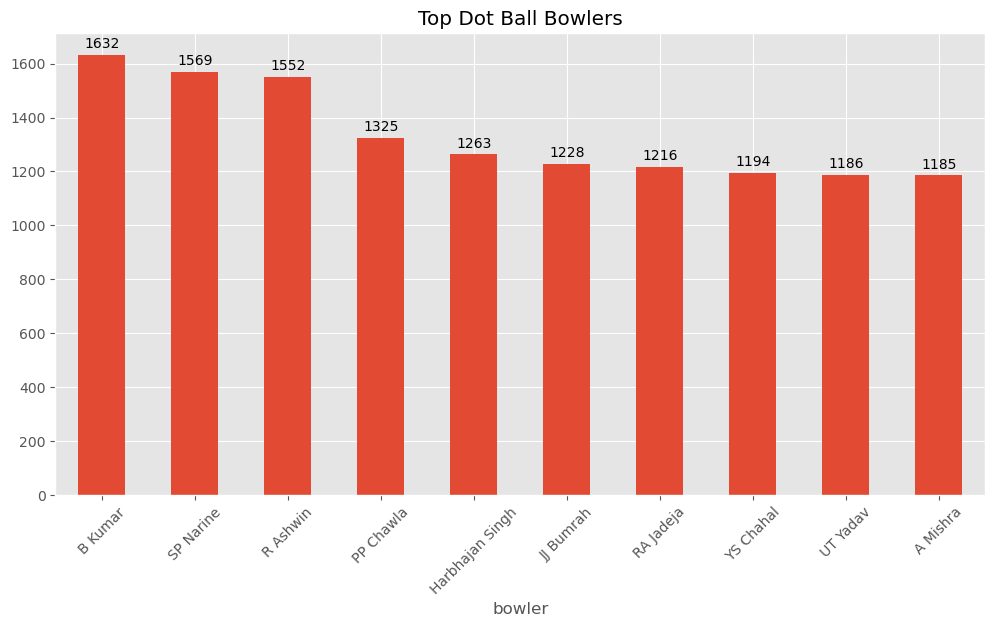

In [13]:
plt.figure(figsize=(12,6))

ax = dotball_count.head(10).plot(kind="bar")

ax.bar_label(ax.containers[0], padding=3)

plt.title("Top Dot Ball Bowlers")

plt.xticks(rotation=45)

plt.show()

Batter Strike Rate

In [6]:
balls = deliveries.groupby("batter")["ball"].count()
balls


batter
A Ashish Reddy     196
A Badoni           505
A Chandila           7
A Chopra            75
A Choudhary         20
                  ... 
Yashpal Singh       67
Younis Khan          7
Yudhvir Singh       16
Yuvraj Singh      2207
Z Khan             141
Name: ball, Length: 673, dtype: int64

In [5]:
runs = deliveries.groupby("batter")["batsman_runs"].sum()
runs

batter
A Ashish Reddy     280
A Badoni           634
A Chandila           4
A Chopra            53
A Choudhary         25
                  ... 
Yashpal Singh       47
Younis Khan          3
Yudhvir Singh       22
Yuvraj Singh      2754
Z Khan             117
Name: batsman_runs, Length: 673, dtype: int64

In [7]:
strike_rate = ((runs / balls) * 100).round(2)

strike_rate = strike_rate.sort_values(ascending=False)

strike_rate.head(10)

batter
L Wood             300.00
B Stanlake         250.00
J Fraser-McGurk    220.00
R Sai Kishore      216.67
Umar Gul           205.26
RS Sodhi           200.00
Shahid Afridi      176.09
I Malhotra         175.00
WG Jacks           172.93
PD Salt            169.61
dtype: float64

Bowler Economy Rate

In [8]:
runs_given = deliveries.groupby("bowler")["total_runs"].sum()
runs_given

bowler
A Ashish Reddy     400
A Badoni            37
A Chandila         245
A Choudhary        144
A Dananjaya         47
                  ... 
Yash Dayal         933
Yash Thakur        702
Yudhvir Singh      125
Yuvraj Singh      1091
Z Khan            2860
Name: total_runs, Length: 530, dtype: int64

In [9]:
balls = deliveries.groupby("bowler")["ball"].count()

In [10]:
overs = balls / 6

In [12]:
economy = (runs_given / overs).round(2)

economy = economy.sort_values(ascending=False)

economy.head(10)

bowler
YBK Jaiswal      36.00
Atharva Taide    24.00
I Malhotra       23.00
LPC Silva        21.00
B Chipli         20.00
P Prasanth       18.00
SN Khan          18.00
RR Bhatkal       17.50
CK Kapugedera    17.29
S Sriram         16.33
dtype: float64

Power Play Runs

In [13]:
powerplay = deliveries[deliveries["match_phase"] == "Powerplay"]

powerplay.groupby("batting_team")["total_runs"].sum().sort_values(ascending=False)

batting_team
Mumbai Indians                 13943
Delhi Capitals                 13861
Kolkata Knight Riders          13632
Punjab Kings                   13526
Chennai Super Kings            12631
Royal Challengers Bangalore    12429
Rajasthan Royals               11774
Sunrisers Hyderabad            10170
Deccan Chargers                 3889
Gujarat Titans                  2504
Lucknow Super Giants            2355
Pune Warriors                   2141
Gujarat Lions                   1818
Royal Challengers Bengaluru      993
Rising Pune Supergiant           877
Kochi Tuskers Kerala             769
Rising Pune Supergiants          744
Name: total_runs, dtype: int64

Death Over Runs

In [15]:
death = deliveries[deliveries["match_phase"] == "Death Overs"]

death.groupby("batting_team")["total_runs"].sum().sort_values(ascending=False)

batting_team
Mumbai Indians                 9598
Chennai Super Kings            9061
Royal Challengers Bangalore    8417
Punjab Kings                   8274
Delhi Capitals                 8184
Kolkata Knight Riders          8053
Rajasthan Royals               7281
Sunrisers Hyderabad            6237
Deccan Chargers                2539
Gujarat Titans                 1823
Lucknow Super Giants           1718
Pune Warriors                  1360
Gujarat Lions                   921
Royal Challengers Bengaluru     611
Rising Pune Supergiant          555
Rising Pune Supergiants         443
Kochi Tuskers Kerala            337
Name: total_runs, dtype: int64

Power play wickets

In [17]:
powerplay.groupby("bowling_team")["is_wicket"].sum().sort_values(ascending=False)

bowling_team
Mumbai Indians                 452
Delhi Capitals                 418
Chennai Super Kings            410
Royal Challengers Bangalore    392
Punjab Kings                   384
Rajasthan Royals               382
Kolkata Knight Riders          381
Sunrisers Hyderabad            283
Deccan Chargers                136
Gujarat Titans                  90
Pune Warriors                   65
Lucknow Super Giants            63
Gujarat Lions                   51
Rising Pune Supergiant          30
Royal Challengers Bengaluru     27
Kochi Tuskers Kerala            24
Rising Pune Supergiants         19
Name: is_wicket, dtype: int64

Death overs wickets

In [19]:
death.groupby("bowling_team")["is_wicket"].sum().sort_values(ascending=False)

bowling_team
Mumbai Indians                 483
Delhi Capitals                 483
Chennai Super Kings            476
Punjab Kings                   465
Kolkata Knight Riders          446
Royal Challengers Bangalore    441
Rajasthan Royals               386
Sunrisers Hyderabad            344
Deccan Chargers                137
Gujarat Titans                  91
Lucknow Super Giants            82
Pune Warriors                   71
Gujarat Lions                   45
Rising Pune Supergiant          34
Rising Pune Supergiants         29
Kochi Tuskers Kerala            20
Royal Challengers Bengaluru     19
Name: is_wicket, dtype: int64

Top Partnership players

In [21]:
partnership = deliveries.groupby(["batter", "non_striker"])["total_runs"].sum()

partnership.sort_values(ascending=False).head(10)

batter          non_striker   
AB de Villiers  V Kohli           1623
CH Gayle        V Kohli           1617
V Kohli         AB de Villiers    1511
DA Warner       S Dhawan          1420
V Kohli         CH Gayle          1185
RV Uthappa      G Gambhir         1077
V Kohli         F du Plessis      1050
Ishan Kishan    RG Sharma          992
F du Plessis    V Kohli            982
S Dhawan        DA Warner          937
Name: total_runs, dtype: int64

Most Consistent Batters

In [22]:

consistency = deliveries.groupby("batter").agg(
    Runs=("batsman_runs", "sum"),
    Balls=("ball", "count")
)

consistency["Strike Rate"] = (
    consistency["Runs"] / consistency["Balls"] * 100
).round(2)

consistency.sort_values("Runs", ascending=False).head(10)

,Runs,Balls,Strike Rate
batter,,,
V Kohli,8014,6236,128.51
S Dhawan,6769,5483,123.45
RG Sharma,6630,5183,127.92
DA Warner,6567,4849,135.43
SK Raina,5536,4177,132.54
MS Dhoni,5243,3947,132.84
AB de Villiers,5181,3487,148.58
CH Gayle,4997,3516,142.12
RV Uthappa,4954,3927,126.15
